# Kenya Climate Analysis (2015-2026)

**Data source:** NASA POWER (Prediction of Worldwide Energy Resources)

**Objective:** Profile temperature, precipitation, and humidity patterns in Kenya to inform COP32 policy recommendations.

**Data Loading & Initial Exploration:**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/kenya.csv')

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


**Missing values report:**

In [3]:
# Missing values report
print("=" * 50)
print("MISSING VALUES REPORT")
print("=" * 50)

missing_count = df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent': missing_percent.round(2)
})

print(missing_report[missing_report['Missing Count'] > 0])

if missing_report[missing_report['Missing Count'] > 0].empty:
    print("\n✅ No missing values found!")

MISSING VALUES REPORT
Empty DataFrame
Columns: [Missing Count, Missing Percent]
Index: []

✅ No missing values found!


**DISTRIBUTION OVERVIEW:**

In [4]:
# Distribution overview
print("\n" + "=" * 50)
print("DISTRIBUTION OVERVIEW")
print("=" * 50)

key_vars = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M']
print(df[key_vars].describe().round(2))


DISTRIBUTION OVERVIEW
           T2M  T2M_MAX  T2M_MIN  PRECTOTCORR     RH2M
count  4108.00  4108.00  4108.00      4108.00  4108.00
mean     20.43    27.84    14.67         1.47    65.85
std       1.44     2.36     1.42         3.18     9.93
min      15.26    18.88     8.97         0.00    28.42
25%      19.46    26.30    13.70         0.10    58.68
50%      20.36    27.88    14.75         0.38    66.22
75%      21.40    29.52    15.75         1.36    73.28
max      25.40    34.27    18.75        51.65    91.07


In [5]:
df = df.replace(-999, np.nan)
df['Country'] = 'Kenya'
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j')
df['Month'] = df['Date'].dt.month

print(f"Kenya data loaded: {df.shape[0]} rows")


Kenya data loaded: 4108 rows


In [6]:
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
print("\nOutliers:")
for col in weather_cols:
    z_scores = (df[col] - df[col].mean()) / df[col].std()
    outliers = (abs(z_scores) > 3).sum()
    print(f"{col}: {outliers}")


Outliers:
T2M: 7
T2M_MAX: 3
T2M_MIN: 9
PRECTOTCORR: 92
RH2M: 6
WS2M: 0
WS2M_MAX: 6


**Average Temperature by Month:**

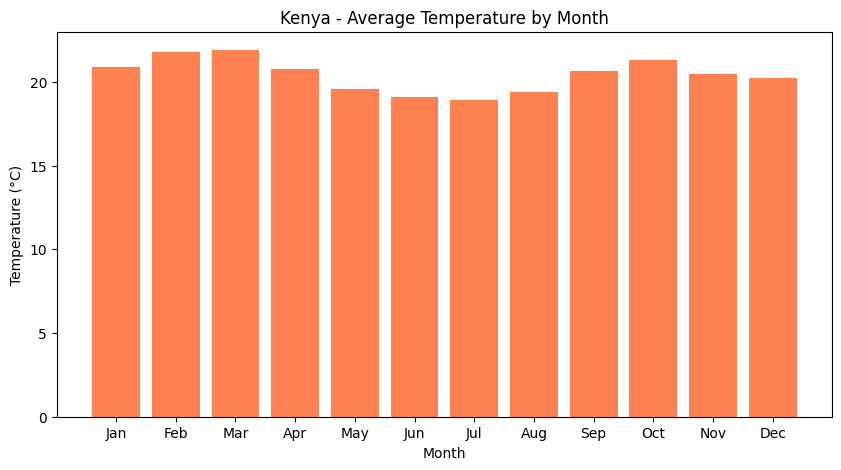

Warmest: Month 3 (21.9°C)
Coolest: Month 7 (18.9°C)


In [7]:
monthly_avg = df.groupby('Month')['T2M'].mean()
plt.figure(figsize=(10, 5))
plt.bar(monthly_avg.index, monthly_avg.values, color='coral')
plt.title('Kenya - Average Temperature by Month')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()
print(f"Warmest: Month {monthly_avg.idxmax()} ({monthly_avg.max():.1f}°C)")
print(f"Coolest: Month {monthly_avg.idxmin()} ({monthly_avg.min():.1f}°C)")


### Temperature by Month (Bar Chart)
**What it shows:** Average temperature across months (Jan-Dec)

**Key findings:**

- Consistent temperatures year-round (typical for equatorial country)
- Little seasonal variation compared to Ethiopia or Sudan

**Why matters for COP32:**

- Stable temperatures benefit agriculture planning
- But low precipitation (1.47 mm/day) creates water stress regardless of stable temps
- Adaptation must focus on water management, not temperature extremes

**Correlation Analysis:**

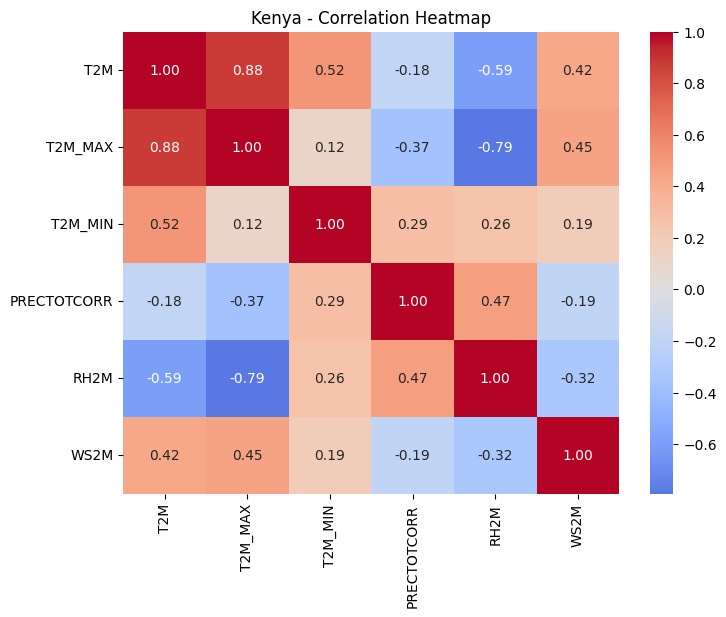

In [8]:
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Kenya - Correlation Heatmap')
plt.show()

In [9]:
corr_matrix = df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']].corr()

print("Strongest correlations:\n")
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.5:
            print(f"{corr_matrix.columns[i]} vs {corr_matrix.columns[j]}: {corr_value:.2f}")

Strongest correlations:

T2M vs T2M_MAX: 0.88
T2M vs T2M_MIN: 0.52
T2M vs RH2M: -0.59
T2M_MAX vs RH2M: -0.79


### Correlation Heatmap
**What it shows:** Relationships between weather variables

**Key findings:**
- Strong negative correlation between max temperature and humidity (-0.79)
- Strong positive correlation between T2M and T2M_MAX (0.88)
- Precipitation weakly correlated with other variables

**Why matters for COP32:**
- Hot days are very dry days → heat stress for humans, crops, livestock
- Agricultural planning must account for simultaneous heat and dryness
- Early warning systems needed for heat-dry compound events

**Daily Precipitation:**

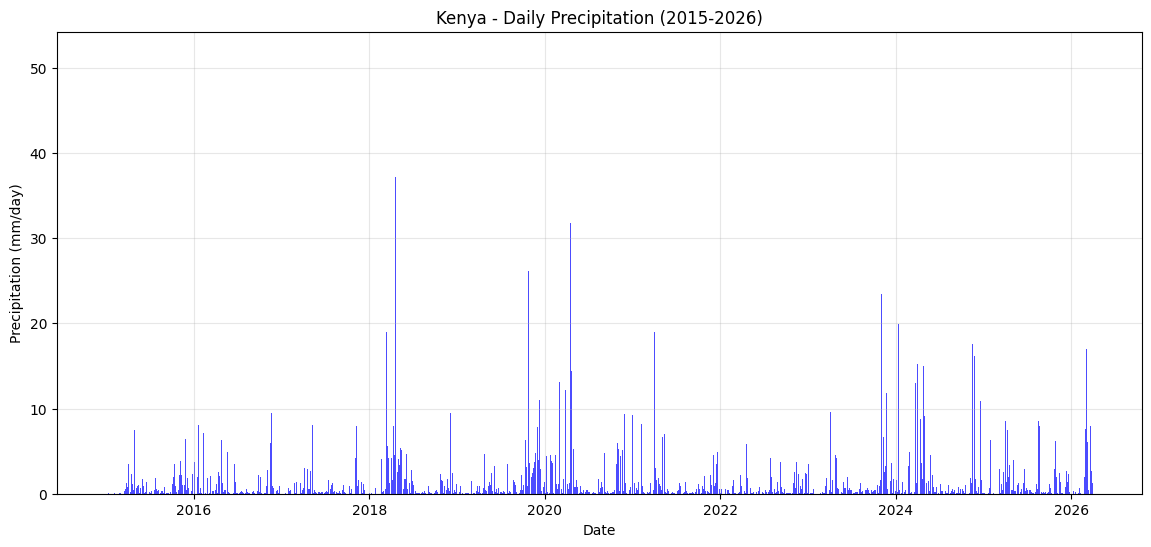

In [10]:
monthly_rain = df.groupby('Date')['PRECTOTCORR'].sum()
plt.figure(figsize=(14, 6))
plt.bar(monthly_rain.index, monthly_rain.values, color='blue', alpha=0.7)
plt.title('Kenya - Daily Precipitation (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm/day)')
plt.grid(True, alpha=0.3)
plt.show()

### Daily Precipitation (Time Series)
**What it shows:** Rainfall patterns 2015-2026

**Key findings:**
- Most days have very low rainfall
- Occasional extreme events (spikes visible)
- Long dry periods between rain events

**Why matters for COP32:**
- Chronic water scarcity is the primary climate stressor
- Flash flood risk exists despite low averages
- Need for both drought resilience AND flood preparedness

**Temperature vs Humidity:**

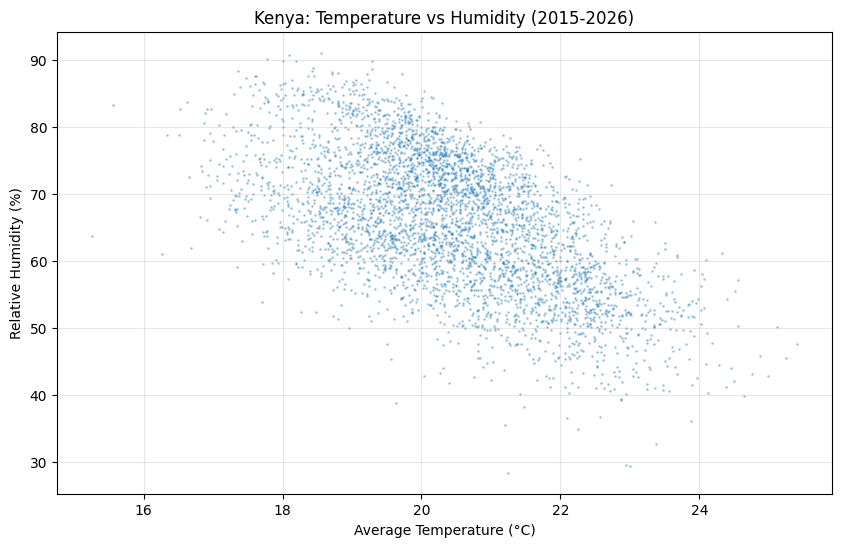

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(df['T2M'], df['RH2M'], alpha=0.3, s=1)
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Kenya: Temperature vs Humidity (2015-2026)')
plt.grid(True, alpha=0.3)
plt.show()

### Temperature vs Humidity (Scatter Plot)
**What it shows:** As temperature rises, humidity falls

**Key findings:**
- Clear negative relationship
- Wider spread at lower temperatures
- Consistent with heatmap finding

**Why matters for COP32:**
- Confirms heat stress risk during warm periods
- Affects labor productivity (outdoor work in hot-dry conditions)
- Health impacts (dehydration, heat exhaustion)

**Temperature Range vs Wind Speed:**

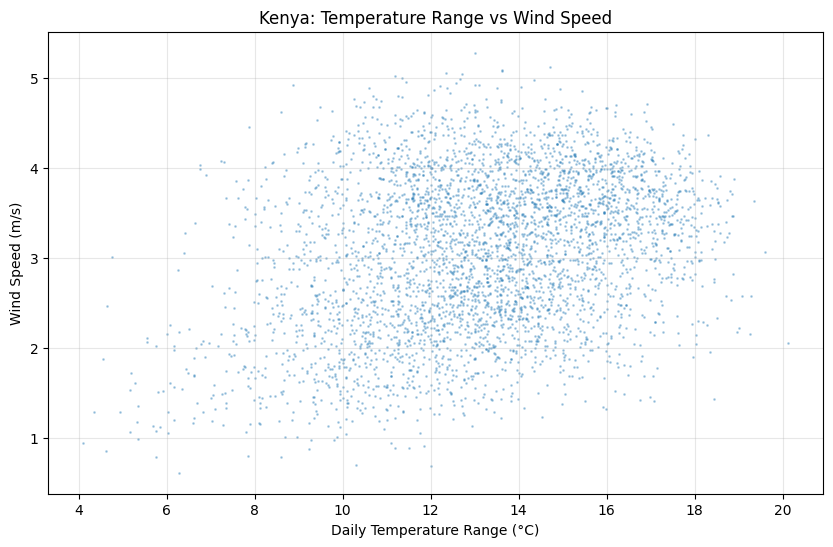

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, s=1)
plt.xlabel('Daily Temperature Range (°C)')
plt.ylabel('Wind Speed (m/s)')
plt.title('Kenya: Temperature Range vs Wind Speed')
plt.grid(True, alpha=0.3)
plt.show()

### Temperature Range vs Wind Speed (Scatter Plot)
**What it shows:** Relationship between daily temperature fluctuation and wind

**Key findings:**
- Weak positive correlation
- Large spread across all wind speeds
- No strong pattern

**Why matters for COP32:**
- Wind is not a primary climate stressor for Kenya
- Focus should remain on water scarcity and heat-dry events

**Precipitation Distribution:**

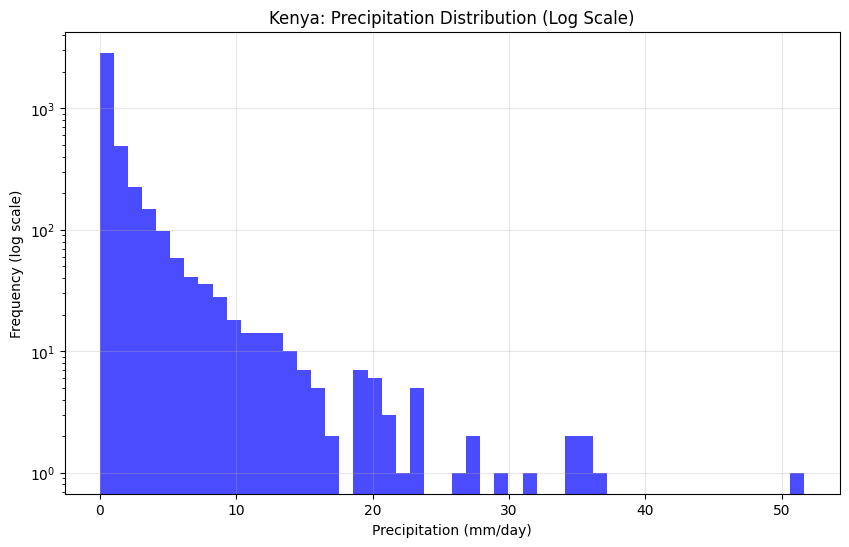

In [13]:
import numpy as np
plt.figure(figsize=(10, 6))
plt.hist(df['PRECTOTCORR'], bins=50, alpha=0.7, color='blue')
plt.yscale('log')
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('Frequency (log scale)')
plt.title('Kenya: Precipitation Distribution (Log Scale)')
plt.grid(True, alpha=0.3)
plt.show()

### Precipitation Distribution (Log Scale Histogram)
**What it shows:** Distribution of daily rainfall amounts

**Key findings:**
- Highly skewed distribution
- Most days: 0-2 mm (very dry)
- Long tail of rare events up to 50+ mm

**Why matters for COP32:**
- "Average" rainfall (1.47 mm/day) is misleading
- Extreme events cause disproportionate damage
- Infrastructure must handle both drought AND rare floods

**Bubble size:**

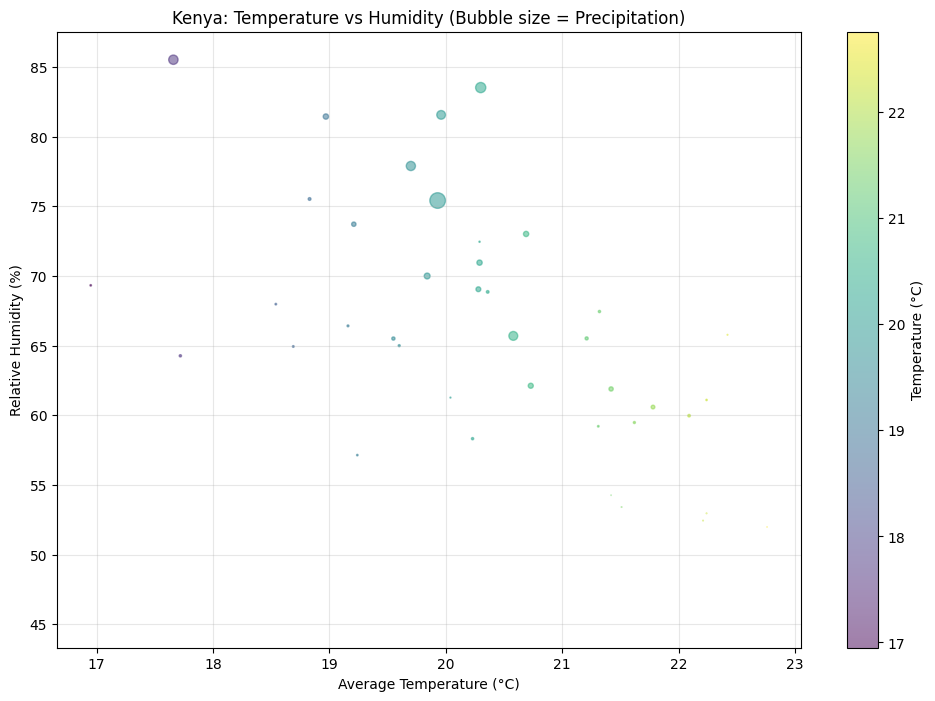

In [14]:
sample = df.iloc[::100, :]

plt.figure(figsize=(12, 8))
scatter = plt.scatter(sample['T2M'], sample['RH2M'], 
                      s=sample['PRECTOTCORR']*10,  # bubble size = precipitation
                      alpha=0.5, c=sample['T2M'], cmap='viridis')
plt.colorbar(label='Temperature (°C)')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Kenya: Temperature vs Humidity (Bubble size = Precipitation)')
plt.grid(True, alpha=0.3)
plt.show()

###  Bubble Chart (Temperature vs Humidity, Size = Precipitation)
**What it shows:** Heavy rain can occur at various temperatures

**Key findings:**
- Most bubbles are small (little rain)
- Occasional large bubbles across temperature range
- No strong temperature-precipitation relationship

**Why matters for COP32:**
- Extreme rain events are unpredictable by temperature alone
- Flood risk exists year-round
- Requires constant preparedness, not seasonal planning

### Conclusion: Kenya's COP32 Position

**Key Findings:**
- Kenya's average temperature is 20.4°C — moderate and stable
- Precipitation is critically low at 1.47 mm/day — second driest in region
- Extreme heat-dry correlation (-0.79) creates compound climate stress
- Rare flood events occur despite low averages

**COP32 Asks:**
1. Drought-resilient agriculture for water-scarce regions
2. Heat-health early warning systems (hot = dry)
3. Flood preparedness for rare but destructive events

**Final Statement:**
Kenya's primary climate crisis is water scarcity, not heat. Adaptation finance must prioritize drought resilience while preparing for compound heat-dry stress and rare flood events.

In [15]:
# Save cleaned Kenya data
df.to_csv('../data/kenya_clean.csv', index=False)
print("✅ Saved: data/kenya_clean.csv")

✅ Saved: data/kenya_clean.csv
